# Face Search Evaluation

## Project Objective

The goal of this stage is to evaluate the one-to-many face search
system using known identities and determine how reliably it ranks the
correct person.

This stage will also investigate the face-distance threshold used to
classify a candidate as a potential match.

## Evaluation Pipeline

```text
Known Query Image
        │
        ▼
Generate Query Embedding
        │
        ▼
Search Stored Face Embeddings
        │
        ▼
Calculate Cosine Distances
        │
        ▼
Rank Candidates by Person
        │
        ▼
Compare Prediction with
Known Identity
        │
        ▼
Evaluate Search Performance
        │
        ▼
Analyze Threshold

In [2]:
import os
import numpy as np
import pandas as pd

from deepface import DeepFace

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
embedding_file = "face_embeddings.npz"

saved_data = np.load(embedding_file)

loaded_embeddings = saved_data["embeddings"]
loaded_metadata = saved_data["metadata"]

print("Embeddings shape:", loaded_embeddings.shape)
print("Metadata shape:", loaded_metadata.shape)
print("Embedding file exists:", os.path.exists(embedding_file))

Embeddings shape: (22, 512)
Metadata shape: (22, 2)
Embedding file exists: True


In [4]:
def cosine_distance(embedding_a, embedding_b):
    similarity = np.dot(embedding_a, embedding_b) / (
        np.linalg.norm(embedding_a) * np.linalg.norm(embedding_b)
    )

    return 1 - similarity


print("Cosine distance function ready!")

Cosine distance function ready!


In [5]:
held_out_query_path = "/tmp/img1_query.jpg"
expected_person = "person1"

print("Query:", held_out_query_path)
print("Expected person:", expected_person)
print("Query exists:", os.path.exists(held_out_query_path))

Query: /tmp/img1_query.jpg
Expected person: person1
Query exists: True


In [6]:
query_embedding_result = DeepFace.represent(
    img_path=held_out_query_path,
    model_name="ArcFace",
    detector_backend="opencv",
    enforce_detection=True
)

query_embedding = np.array(
    query_embedding_result[0]["embedding"]
)

print("Query embedding shape:", query_embedding.shape)

Query embedding shape: (512,)


In [7]:
evaluation_results = []

for index, database_embedding in enumerate(loaded_embeddings):

    distance = cosine_distance(
        query_embedding,
        database_embedding
    )

    evaluation_results.append({
        "person": loaded_metadata[index][0],
        "image": loaded_metadata[index][1],
        "distance": distance
    })

evaluation_results = sorted(
    evaluation_results,
    key=lambda x: x["distance"]
)

print("Top 5 candidates:")
print()

for result in evaluation_results[:5]:
    print(
        f"{result['person']} | "
        f"{result['image']} | "
        f"distance: {result['distance']:.4f}"
    )

Top 5 candidates:

person1 | img4.jpg | distance: 0.4969
person1 | img2.jpg | distance: 0.5078
person1 | img11.jpg | distance: 0.5182
person1 | img7.jpg | distance: 0.5230
person1 | img5.jpg | distance: 0.5399


In [8]:
predicted_person = evaluation_results[0]["person"]

top1_correct = predicted_person == expected_person

print("Expected person:", expected_person)
print("Predicted person:", predicted_person)
print("Top-1 correct:", top1_correct)
print("Top-1 distance:", round(evaluation_results[0]["distance"], 4))

Expected person: person1
Predicted person: person1
Top-1 correct: True
Top-1 distance: 0.4969


In [9]:
identity_groups = {
    "person1": ["img1.jpg", "img2.jpg", "img4.jpg", "img5.jpg",
                "img6.jpg", "img7.jpg", "img10.jpg", "img11.jpg"],
    "person2": ["img3.jpg", "img12.jpg"],
    "person3": ["img13.jpg", "img14.jpg", "img15.jpg"],
    "person4": ["img16.jpg", "img17.jpg"],
    "person5": ["img18.jpg", "img19.jpg"],
    "person6": ["img20.jpg", "img21.jpg"],
    "person7": ["img22.jpg", "img23.jpg"],
    "person8": ["img24.jpg", "img25.jpg"]
}

print("Identity groups created:", len(identity_groups))

for person, images in identity_groups.items():
    print(f"{person}: {len(images)} images")

Identity groups created: 8
person1: 8 images
person2: 2 images
person3: 3 images
person4: 2 images
person5: 2 images
person6: 2 images
person7: 2 images
person8: 2 images


In [10]:
dataset_dir = "deepface_repo/tests/unit/dataset"

available_images = set(os.listdir(dataset_dir))

for person, images in identity_groups.items():
    available = [img for img in images if img in available_images]
    missing = [img for img in images if img not in available_images]

    print(f"{person}:")
    print(f"  Available: {len(available)}")
    print(f"  Missing:   {len(missing)}")

    if missing:
        print(f"  Missing files: {missing}")

person1:
  Available: 8
  Missing:   0
person2:
  Available: 2
  Missing:   0
person3:
  Available: 3
  Missing:   0
person4:
  Available: 2
  Missing:   0
person5:
  Available: 2
  Missing:   0
person6:
  Available: 2
  Missing:   0
person7:
  Available: 2
  Missing:   0
person8:
  Available: 2
  Missing:   0


In [11]:
test_person = "person2"
test_image = "img3.jpg"

test_query_path = os.path.join(
    dataset_dir,
    test_image
)

print("Test person:", test_person)
print("Query image:", test_image)
print("Query exists:", os.path.exists(test_query_path))

Test person: person2
Query image: img3.jpg
Query exists: True


In [12]:
test_query_embedding = DeepFace.represent(
    img_path=test_query_path,
    model_name="ArcFace",
    enforce_detection=True
)[0]["embedding"]

test_query_embedding = np.array(test_query_embedding)

print("Embedding shape:", test_query_embedding.shape)

Embedding shape: (512,)


In [13]:
test_results = []

for index, database_embedding in enumerate(loaded_embeddings):
    distance = cosine_distance(
        test_query_embedding,
        database_embedding
    )

    test_results.append({
        "person": loaded_metadata[index][0],
        "image": loaded_metadata[index][1],
        "distance": distance
    })

test_results = sorted(
    test_results,
    key=lambda x: x["distance"]
)

print("Top 5 matches:")
for result in test_results[:5]:
    print(
        result["person"],
        result["image"],
        round(result["distance"], 4)
    )

Top 5 matches:
person2 img3.jpg -0.0
person2 img12.jpg 0.6516
person1 img5.jpg 0.7389
person1 img6.jpg 0.7969
person8 img25.jpg 0.8346


In [14]:
filtered_results = [
    result
    for result in test_results
    if result["image"] != test_image
]

print("Top 5 matches after excluding query image:")

for result in filtered_results[:5]:
    print(
        result["person"],
        result["image"],
        round(result["distance"], 4)
    )

Top 5 matches after excluding query image:
person2 img12.jpg 0.6516
person1 img5.jpg 0.7389
person1 img6.jpg 0.7969
person8 img25.jpg 0.8346
person1 img7.jpg 0.8528


In [15]:
predicted_person = filtered_results[0]["person"]
top1_distance = filtered_results[0]["distance"]

top1_correct = predicted_person == test_person

print("Expected person:", test_person)
print("Predicted person:", predicted_person)
print("Top-1 distance:", round(top1_distance, 4))
print("Top-1 correct:", top1_correct)

Expected person: person2
Predicted person: person2
Top-1 distance: 0.6516
Top-1 correct: True


In [16]:
test_person = "person3"
test_image = "img13.jpg"

test_query_path = os.path.join(
    dataset_dir,
    test_image
)

print("Test person:", test_person)
print("Query image:", test_image)
print("Query exists:", os.path.exists(test_query_path))

Test person: person3
Query image: img13.jpg
Query exists: True


In [17]:
test_query_embedding = DeepFace.represent(
    img_path=test_query_path,
    model_name="ArcFace",
    enforce_detection=True
)[0]["embedding"]

test_query_embedding = np.array(test_query_embedding)

print("Embedding shape:", test_query_embedding.shape)

Embedding shape: (512,)


In [18]:
test_results = []

for index, database_embedding in enumerate(loaded_embeddings):
    distance = cosine_distance(
        test_query_embedding,
        database_embedding
    )

    test_results.append({
        "person": loaded_metadata[index][0],
        "image": loaded_metadata[index][1],
        "distance": distance
    })

test_results = sorted(
    test_results,
    key=lambda x: x["distance"]
)

print("Top 5 matches:")

for result in test_results[:5]:
    print(
        result["person"],
        result["image"],
        round(result["distance"], 4)
    )

Top 5 matches:
person3 img13.jpg 0.0
person3 img14.jpg 0.241
person3 img15.jpg 0.4041
person4 img16.jpg 0.8616
person8 img24.jpg 0.8621


In [19]:
filtered_results = [
    result
    for result in test_results
    if result["image"] != test_image
]

print("Top 5 matches after excluding query image:")

for result in filtered_results[:5]:
    print(
        result["person"],
        result["image"],
        round(result["distance"], 4)
    )

Top 5 matches after excluding query image:
person3 img14.jpg 0.241
person3 img15.jpg 0.4041
person4 img16.jpg 0.8616
person8 img24.jpg 0.8621
person4 img17.jpg 0.8692


In [20]:
predicted_person = filtered_results[0]["person"]
top1_distance = filtered_results[0]["distance"]

top1_correct = predicted_person == test_person

print("Expected person:", test_person)
print("Predicted person:", predicted_person)
print("Top-1 distance:", round(top1_distance, 4))
print("Top-1 correct:", top1_correct)

Expected person: person3
Predicted person: person3
Top-1 distance: 0.241
Top-1 correct: True


In [21]:
test_queries = [
    ("person1", "img1.jpg"),
    ("person2", "img3.jpg"),
    ("person3", "img13.jpg"),
    ("person4", "img16.jpg"),
    ("person5", "img18.jpg"),
    ("person6", "img20.jpg"),
    ("person7", "img22.jpg"),
    ("person8", "img24.jpg")
]

print("Total test queries:", len(test_queries))

for person, image in test_queries:
    path = os.path.join(dataset_dir, image)
    print(person, image, os.path.exists(path))

Total test queries: 8
person1 img1.jpg True
person2 img3.jpg True
person3 img13.jpg True
person4 img16.jpg True
person5 img18.jpg True
person6 img20.jpg True
person7 img22.jpg True
person8 img24.jpg True


In [22]:
evaluation_summary = []

for test_person, test_image in test_queries:

    # Load query image path
    test_query_path = os.path.join(dataset_dir, test_image)

    # Generate query embedding
    test_query_embedding = DeepFace.represent(
        img_path=test_query_path,
        model_name="ArcFace",
        enforce_detection=True
    )[0]["embedding"]

    test_query_embedding = np.array(test_query_embedding)

    # Compare query with stored database embeddings
    results = []

    for index, database_embedding in enumerate(loaded_embeddings):

        # Exclude the query image itself
        if loaded_metadata[index][1] == test_image:
            continue

        distance = cosine_distance(
            test_query_embedding,
            database_embedding
        )

        results.append({
            "person": loaded_metadata[index][0],
            "image": loaded_metadata[index][1],
            "distance": distance
        })

    # Rank by smallest distance
    results = sorted(
        results,
        key=lambda x: x["distance"]
    )

    # Top-1 prediction
    predicted_person = results[0]["person"]
    top1_distance = results[0]["distance"]

    evaluation_summary.append({
        "query_person": test_person,
        "query_image": test_image,
        "predicted_person": predicted_person,
        "top1_distance": top1_distance,
        "correct": predicted_person == test_person
    })

print("Evaluation completed.")

for result in evaluation_summary:
    print(
        result["query_person"],
        "→",
        result["predicted_person"],
        "| distance:",
        round(result["top1_distance"], 4),
        "| correct:",
        result["correct"]
    )

Evaluation completed.
person1 → person1 | distance: 0.4969 | correct: True
person2 → person2 | distance: 0.6516 | correct: True
person3 → person3 | distance: 0.241 | correct: True
person4 → person4 | distance: 0.2622 | correct: True
person5 → person5 | distance: 0.2283 | correct: True
person6 → person6 | distance: 0.2622 | correct: True
person7 → person7 | distance: 0.3064 | correct: True
person8 → person8 | distance: 0.4551 | correct: True


In [23]:
correct_predictions = sum(
    result["correct"]
    for result in evaluation_summary
)

total_queries = len(evaluation_summary)

top1_accuracy = (
    correct_predictions / total_queries
) * 100

print("Correct predictions:", correct_predictions)
print("Total queries:", total_queries)
print("Top-1 Accuracy:", round(top1_accuracy, 2), "%")

Correct predictions: 8
Total queries: 8
Top-1 Accuracy: 100.0 %


In [24]:
top3_results = []

for test_person, test_image in test_queries:

    test_query_path = os.path.join(dataset_dir, test_image)

    # Generate query embedding
    query_embedding = DeepFace.represent(
        img_path=test_query_path,
        model_name="ArcFace",
        enforce_detection=True
    )[0]["embedding"]

    query_embedding = np.array(query_embedding)

    # Compare against database, excluding the query image
    results = []

    for index, database_embedding in enumerate(loaded_embeddings):

        if loaded_metadata[index][1] == test_image:
            continue

        distance = cosine_distance(
            query_embedding,
            database_embedding
        )

        results.append({
            "person": loaded_metadata[index][0],
            "image": loaded_metadata[index][1],
            "distance": distance
        })

    results = sorted(
        results,
        key=lambda x: x["distance"]
    )

    # Get top 3 unique people
    top3_people = []

    for result in results:
        if result["person"] not in top3_people:
            top3_people.append(result["person"])

        if len(top3_people) == 3:
            break

    correct = test_person in top3_people

    top3_results.append({
        "query_person": test_person,
        "top3_people": top3_people,
        "correct": correct
    })

for result in top3_results:
    print(
        result["query_person"],
        "→",
        result["top3_people"],
        "| correct:",
        result["correct"]
    )

person1 → [np.str_('person1'), np.str_('person8'), np.str_('person7')] | correct: True
person2 → [np.str_('person2'), np.str_('person1'), np.str_('person8')] | correct: True
person3 → [np.str_('person3'), np.str_('person4'), np.str_('person8')] | correct: True
person4 → [np.str_('person4'), np.str_('person3'), np.str_('person6')] | correct: True
person5 → [np.str_('person5'), np.str_('person1'), np.str_('person7')] | correct: True
person6 → [np.str_('person6'), np.str_('person5'), np.str_('person4')] | correct: True
person7 → [np.str_('person7'), np.str_('person1'), np.str_('person5')] | correct: True
person8 → [np.str_('person8'), np.str_('person2'), np.str_('person1')] | correct: True


In [25]:
distance_analysis = []

for test_person, test_image in test_queries:

    test_query_path = os.path.join(dataset_dir, test_image)

    query_embedding = DeepFace.represent(
        img_path=test_query_path,
        model_name="ArcFace",
        enforce_detection=True
    )[0]["embedding"]

    query_embedding = np.array(query_embedding)

    same_person_distances = []
    different_person_distances = []

    for index, database_embedding in enumerate(loaded_embeddings):

        # Exclude the query image itself
        if loaded_metadata[index][1] == test_image:
            continue

        distance = cosine_distance(
            query_embedding,
            database_embedding
        )

        database_person = loaded_metadata[index][0]

        if database_person == test_person:
            same_person_distances.append(distance)
        else:
            different_person_distances.append(distance)

    best_same = min(same_person_distances)
    best_different = min(different_person_distances)

    distance_analysis.append({
        "person": test_person,
        "best_same_person_distance": best_same,
        "best_different_person_distance": best_different
    })

for result in distance_analysis:
    print(
        result["person"],
        "| same person:",
        round(result["best_same_person_distance"], 4),
        "| different person:",
        round(result["best_different_person_distance"], 4)
    )

person1 | same person: 0.4969 | different person: 0.83
person2 | same person: 0.6516 | different person: 0.7389
person3 | same person: 0.241 | different person: 0.8616
person4 | same person: 0.2622 | different person: 0.8616
person5 | same person: 0.2283 | different person: 0.8064
person6 | same person: 0.2622 | different person: 0.8232
person7 | same person: 0.3064 | different person: 0.7397
person8 | same person: 0.4551 | different person: 0.8157


In [26]:
thresholds = np.arange(0.40, 0.91, 0.02)

print("Thresholds to test:")
print(thresholds)

Thresholds to test:
[0.4  0.42 0.44 0.46 0.48 0.5  0.52 0.54 0.56 0.58 0.6  0.62 0.64 0.66
 0.68 0.7  0.72 0.74 0.76 0.78 0.8  0.82 0.84 0.86 0.88 0.9 ]


In [27]:
threshold_results = []

for threshold in thresholds:

    correct_matches = 0

    for result in distance_analysis:

        same_distance = result["best_same_person_distance"]

        if same_distance <= threshold:
            correct_matches += 1

    acceptance_rate = (
        correct_matches / len(distance_analysis)
    ) * 100

    threshold_results.append({
        "threshold": threshold,
        "correct_matches": correct_matches,
        "acceptance_rate": acceptance_rate
    })

for result in threshold_results:
    print(
        "Threshold:",
        round(result["threshold"], 2),
        "| accepted:",
        result["correct_matches"],
        "/",
        len(distance_analysis),
        "| acceptance:",
        round(result["acceptance_rate"], 1),
        "%"
    )

Threshold: 0.4 | accepted: 5 / 8 | acceptance: 62.5 %
Threshold: 0.42 | accepted: 5 / 8 | acceptance: 62.5 %
Threshold: 0.44 | accepted: 5 / 8 | acceptance: 62.5 %
Threshold: 0.46 | accepted: 6 / 8 | acceptance: 75.0 %
Threshold: 0.48 | accepted: 6 / 8 | acceptance: 75.0 %
Threshold: 0.5 | accepted: 7 / 8 | acceptance: 87.5 %
Threshold: 0.52 | accepted: 7 / 8 | acceptance: 87.5 %
Threshold: 0.54 | accepted: 7 / 8 | acceptance: 87.5 %
Threshold: 0.56 | accepted: 7 / 8 | acceptance: 87.5 %
Threshold: 0.58 | accepted: 7 / 8 | acceptance: 87.5 %
Threshold: 0.6 | accepted: 7 / 8 | acceptance: 87.5 %
Threshold: 0.62 | accepted: 7 / 8 | acceptance: 87.5 %
Threshold: 0.64 | accepted: 7 / 8 | acceptance: 87.5 %
Threshold: 0.66 | accepted: 8 / 8 | acceptance: 100.0 %
Threshold: 0.68 | accepted: 8 / 8 | acceptance: 100.0 %
Threshold: 0.7 | accepted: 8 / 8 | acceptance: 100.0 %
Threshold: 0.72 | accepted: 8 / 8 | acceptance: 100.0 %
Threshold: 0.74 | accepted: 8 / 8 | acceptance: 100.0 %
Threshold

In [28]:
false_accept_results = []

for threshold in thresholds:

    false_accepts = 0

    for result in distance_analysis:

        different_distance = result["best_different_person_distance"]

        if different_distance <= threshold:
            false_accepts += 1

    false_accept_results.append({
        "threshold": threshold,
        "false_accepts": false_accepts,
        "false_accept_rate": (
            false_accepts / len(distance_analysis)
        ) * 100
    })

for result in false_accept_results:
    print(
        "Threshold:",
        round(result["threshold"], 2),
        "| false accepts:",
        result["false_accepts"],
        "/",
        len(distance_analysis),
        "| false accept rate:",
        round(result["false_accept_rate"], 1),
        "%"
    )

Threshold: 0.4 | false accepts: 0 / 8 | false accept rate: 0.0 %
Threshold: 0.42 | false accepts: 0 / 8 | false accept rate: 0.0 %
Threshold: 0.44 | false accepts: 0 / 8 | false accept rate: 0.0 %
Threshold: 0.46 | false accepts: 0 / 8 | false accept rate: 0.0 %
Threshold: 0.48 | false accepts: 0 / 8 | false accept rate: 0.0 %
Threshold: 0.5 | false accepts: 0 / 8 | false accept rate: 0.0 %
Threshold: 0.52 | false accepts: 0 / 8 | false accept rate: 0.0 %
Threshold: 0.54 | false accepts: 0 / 8 | false accept rate: 0.0 %
Threshold: 0.56 | false accepts: 0 / 8 | false accept rate: 0.0 %
Threshold: 0.58 | false accepts: 0 / 8 | false accept rate: 0.0 %
Threshold: 0.6 | false accepts: 0 / 8 | false accept rate: 0.0 %
Threshold: 0.62 | false accepts: 0 / 8 | false accept rate: 0.0 %
Threshold: 0.64 | false accepts: 0 / 8 | false accept rate: 0.0 %
Threshold: 0.66 | false accepts: 0 / 8 | false accept rate: 0.0 %
Threshold: 0.68 | false accepts: 0 / 8 | false accept rate: 0.0 %
Threshold: 0.

In [29]:
all_comparisons = []

for test_person, test_image in test_queries:

    test_query_path = os.path.join(dataset_dir, test_image)

    query_embedding = DeepFace.represent(
        img_path=test_query_path,
        model_name="ArcFace",
        enforce_detection=True
    )[0]["embedding"]

    query_embedding = np.array(query_embedding)

    for index, database_embedding in enumerate(loaded_embeddings):

        database_person = loaded_metadata[index][0]
        database_image = loaded_metadata[index][1]

        # Exclude the query image itself
        if database_image == test_image:
            continue

        distance = cosine_distance(
            query_embedding,
            database_embedding
        )

        is_same_person = database_person == test_person

        all_comparisons.append({
            "query_person": test_person,
            "query_image": test_image,
            "database_person": database_person,
            "database_image": database_image,
            "distance": distance,
            "same_person": is_same_person
        })

print("Total comparisons:", len(all_comparisons))

same_count = sum(
    comparison["same_person"]
    for comparison in all_comparisons
)

different_count = len(all_comparisons) - same_count

print("Same-person comparisons:", same_count)
print("Different-person comparisons:", different_count)

Total comparisons: 169
Same-person comparisons: 15
Different-person comparisons: 154


In [30]:
threshold_metrics = []

for threshold in thresholds:

    true_accepts = 0
    false_rejects = 0
    true_rejects = 0
    false_accepts = 0

    for comparison in all_comparisons:

        distance = comparison["distance"]
        same_person = comparison["same_person"]

        # Distance <= threshold means ACCEPT
        predicted_same = distance <= threshold

        if same_person and predicted_same:
            true_accepts += 1

        elif same_person and not predicted_same:
            false_rejects += 1

        elif not same_person and not predicted_same:
            true_rejects += 1

        elif not same_person and predicted_same:
            false_accepts += 1

    far = (
        false_accepts / different_count
    ) * 100

    frr = (
        false_rejects / same_count
    ) * 100

    threshold_metrics.append({
        "threshold": threshold,
        "true_accepts": true_accepts,
        "false_rejects": false_rejects,
        "true_rejects": true_rejects,
        "false_accepts": false_accepts,
        "far": far,
        "frr": frr
    })

for result in threshold_metrics:
    print(
        "Threshold:", round(result["threshold"], 2),
        "| FAR:", round(result["far"], 2), "%",
        "| FRR:", round(result["frr"], 2), "%",
        "| FA:", result["false_accepts"],
        "| FR:", result["false_rejects"]
    )

Threshold: 0.4 | FAR: 0.0 % | FRR: 66.67 % | FA: 0 | FR: 10
Threshold: 0.42 | FAR: 0.0 % | FRR: 60.0 % | FA: 0 | FR: 9
Threshold: 0.44 | FAR: 0.0 % | FRR: 60.0 % | FA: 0 | FR: 9
Threshold: 0.46 | FAR: 0.0 % | FRR: 53.33 % | FA: 0 | FR: 8
Threshold: 0.48 | FAR: 0.0 % | FRR: 53.33 % | FA: 0 | FR: 8
Threshold: 0.5 | FAR: 0.0 % | FRR: 46.67 % | FA: 0 | FR: 7
Threshold: 0.52 | FAR: 0.0 % | FRR: 33.33 % | FA: 0 | FR: 5
Threshold: 0.54 | FAR: 0.0 % | FRR: 20.0 % | FA: 0 | FR: 3
Threshold: 0.56 | FAR: 0.0 % | FRR: 20.0 % | FA: 0 | FR: 3
Threshold: 0.58 | FAR: 0.0 % | FRR: 20.0 % | FA: 0 | FR: 3
Threshold: 0.6 | FAR: 0.0 % | FRR: 20.0 % | FA: 0 | FR: 3
Threshold: 0.62 | FAR: 0.0 % | FRR: 13.33 % | FA: 0 | FR: 2
Threshold: 0.64 | FAR: 0.0 % | FRR: 6.67 % | FA: 0 | FR: 1
Threshold: 0.66 | FAR: 0.0 % | FRR: 0.0 % | FA: 0 | FR: 0
Threshold: 0.68 | FAR: 0.0 % | FRR: 0.0 % | FA: 0 | FR: 0
Threshold: 0.7 | FAR: 0.0 % | FRR: 0.0 % | FA: 0 | FR: 0
Threshold: 0.72 | FAR: 0.0 % | FRR: 0.0 % | FA: 0 | FR: 

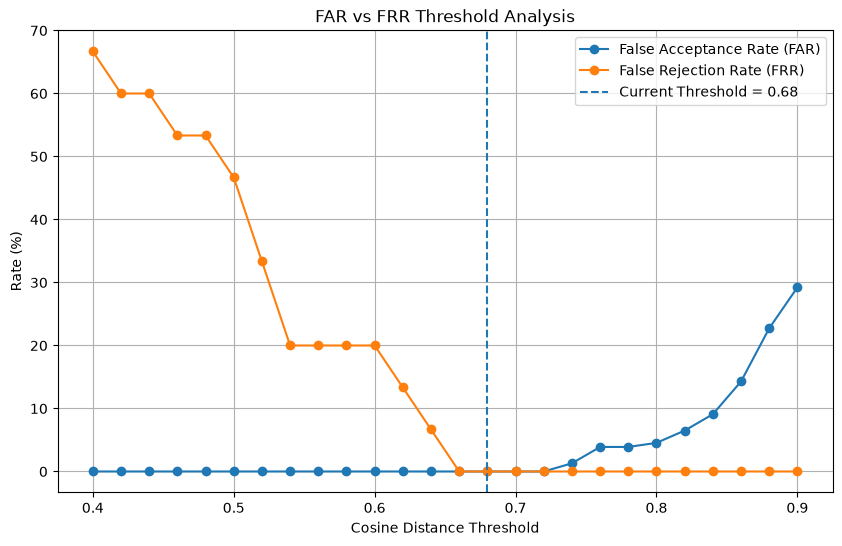

In [31]:
import matplotlib.pyplot as plt

threshold_values = [
    result["threshold"]
    for result in threshold_metrics
]

far_values = [
    result["far"]
    for result in threshold_metrics
]

frr_values = [
    result["frr"]
    for result in threshold_metrics
]

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_values,
    far_values,
    marker="o",
    label="False Acceptance Rate (FAR)"
)

plt.plot(
    threshold_values,
    frr_values,
    marker="o",
    label="False Rejection Rate (FRR)"
)

plt.axvline(
    x=0.68,
    linestyle="--",
    label="Current Threshold = 0.68"
)

plt.xlabel("Cosine Distance Threshold")
plt.ylabel("Rate (%)")
plt.title("FAR vs FRR Threshold Analysis")

plt.legend()
plt.grid(True)
plt.show()

## FAR vs FRR Threshold Analysis

The threshold was evaluated using 169 face comparisons, including 15
same-person comparisons and 154 different-person comparisons.

The results show a clear trade-off between False Rejection Rate (FRR) and
False Acceptance Rate (FAR).

At lower thresholds, FRR is higher because some genuine matches are rejected.
As the threshold increases, FRR decreases and reaches 0% at a threshold of
0.66.

The False Acceptance Rate remains 0% up to a threshold of 0.72. Above 0.72,
false accepts begin to appear and FAR increases as the threshold becomes more
permissive.

The current threshold of 0.68 lies within the range where both FAR and FRR
are 0% on this evaluation dataset.

Therefore, 0.68 is retained as the operating threshold for the current
prototype.

However, this threshold should not be considered universally optimal. The
evaluation dataset is small and controlled, and a larger and more diverse
dataset would be required to calibrate the threshold for real-world
deployment.

In [33]:
same_distances = [
    comparison["distance"]
    for comparison in all_comparisons
    if comparison["same_person"]
]

different_distances = [
    comparison["distance"]
    for comparison in all_comparisons
    if not comparison["same_person"]
]

print("Same-person comparisons:", len(same_distances))
print("Different-person comparisons:", len(different_distances))

print(
    "Same-person distance range:",
    round(min(same_distances), 4),
    "to",
    round(max(same_distances), 4)
)

print(
    "Different-person distance range:",
    round(min(different_distances), 4),
    "to",
    round(max(different_distances), 4)
)

Same-person comparisons: 15
Different-person comparisons: 154
Same-person distance range: 0.2283 to 0.6516
Different-person distance range: 0.7389 to 1.2489


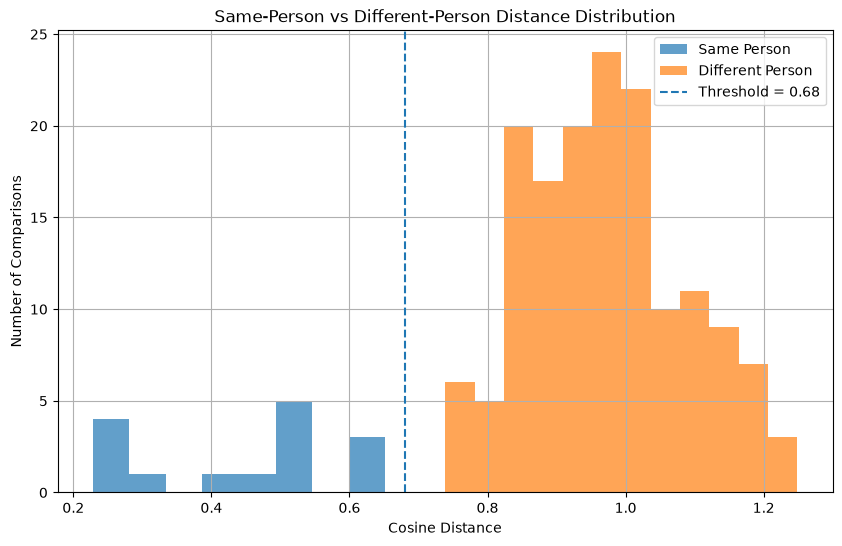

In [34]:
plt.figure(figsize=(10, 6))

plt.hist(
    same_distances,
    bins=8,
    alpha=0.7,
    label="Same Person"
)

plt.hist(
    different_distances,
    bins=12,
    alpha=0.7,
    label="Different Person"
)

plt.axvline(
    x=0.68,
    linestyle="--",
    label="Threshold = 0.68"
)

plt.xlabel("Cosine Distance")
plt.ylabel("Number of Comparisons")
plt.title("Same-Person vs Different-Person Distance Distribution")

plt.legend()
plt.grid(True)
plt.show()

## Conclusion

The one-to-many face search system was evaluated using a leave-one-out
evaluation strategy across 8 identities.

The system achieved 100% Top-1 accuracy (8/8) and 100% Top-3 accuracy (8/8)
on the selected evaluation queries.

A total of 169 face comparisons were analyzed, including 15 same-person
comparisons and 154 different-person comparisons. Using a cosine distance
threshold of 0.68 resulted in 0% False Acceptance Rate (FAR) and 0% False
Rejection Rate (FRR) on this evaluation dataset.

The distance distribution also showed a clear separation between same-person
and different-person comparisons. Same-person distances ranged from 0.2283
to 0.6516, while different-person distances ranged from 0.7389 to 1.2489.
The threshold of 0.68 lies between these two ranges.

Therefore, the current threshold of 0.68 is retained for the prototype.

These results are promising but should not be interpreted as real-world
accuracy. The evaluation dataset is small and controlled. A larger and more
diverse dataset containing variations in lighting, pose, image quality,
occlusion, camera conditions, and age would be required for reliable
real-world threshold calibration.

The evaluation confirms that the current ArcFace-based one-to-many search
pipeline is functioning correctly and provides a foundation for the next
stage of the Missing Person Finder application.